## Intial Setup

In [177]:
import numpy as np
import libTruss
import libTruss_dev  

## Material

In [178]:
class materials:
    def __init__(self):  # , nu, rho):
        self.E = 210e9
        self.sigl = 250e6
        self.rho = 7860


mat = materials()



## Geometry

In [179]:
Nodes = np.array([[0,0],
                  [4,0],
                  [8,0],
                  [0,1],
                  [4,1],
                  [8,1],
                  [0,2],
                  [4,2],
                  [8,2],
                 ])
Nodes = Nodes*12
# build connectivity
Connectivity = np.array([[0,3],
                         [1,4],
                         [2,5],
                         [3,6],
                         [4,7],
                         [5,8],
                         [0,1],
                         [1,2],
                         [3,4],
                         [4,5],
                         [6,7],
                         [7,8],
                         [0,4],
                         [3,1],
                         [1,5],
                         [4,2],
                         [3,7],
                         [6,4],
                         [4,8],
                         [5,7],
                        ])


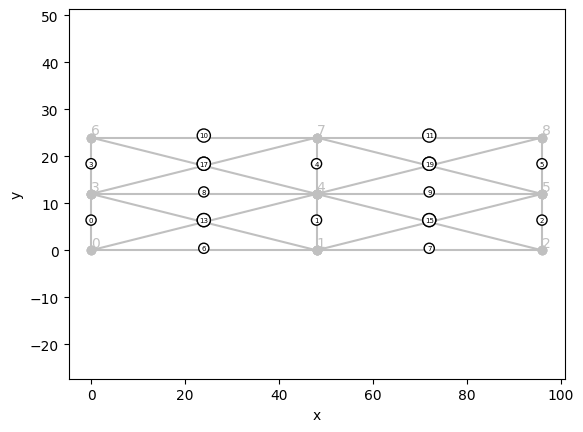

Number of nodes : 9
Number of elements : 20


In [180]:
# show mesh
libTruss.plotResults(Nodes, Connectivity, scaleFactor=1,
                     options={'showNumPoints':True,'showNumElem':True})
print('Number of nodes : {}'.format(Nodes.shape[0]))
print('Number of elements : {}'.format(Connectivity.shape[0]))

In [181]:
# boundary conditions
forceBC = {"type": "nodes", "nodes": [7], "value": np.array([0, -6e3])}

dispBC = [{"type": "nodes", "nodes": [0,2], "value": np.array([0, 0])},
         {"type": "nodes", "nodes": [3,5,6,8], "value": np.array([0, np.nan])}]

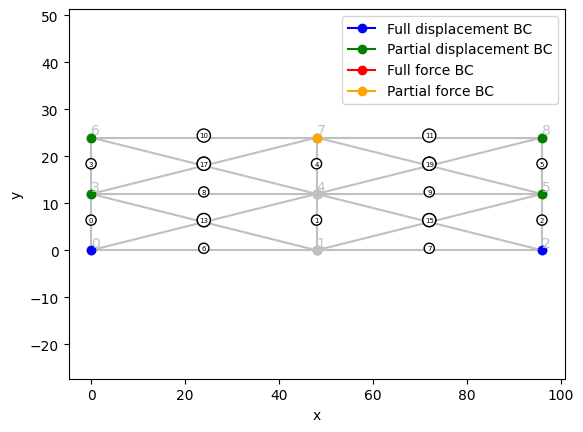

In [182]:
# show mesh
libTruss.plotResults(Nodes, Connectivity, scaleFactor=1,
                     bc={'force':forceBC,'disp':dispBC},
                     options={'showNumPoints':True,'showNumElem':True})


## Results

In [183]:
# --- 1. Define Properties & loads ---
nElem = Connectivity.shape[0]
Areas = np.ones(nElem) * 10e-4  # Define cross-sections (e.g., 10 cm^2)

# Convert Force BCs for the solver
loads_list = []
if forceBC['type'] == 'nodes':
    for n in forceBC['nodes']:
        loads_list.append({'node': n, 'value': forceBC['value']})

# Convert Displacement BCs to fixed indices
fixed_dofs = []
for bc in dispBC:
    nodes = bc['nodes']
    vals = bc['value']
    for n in nodes:
        if not np.isnan(vals[0]): fixed_dofs.append(2*n)     # Fix X
        if not np.isnan(vals[1]): fixed_dofs.append(2*n + 1) # Fix Y
bc_indices = np.array(fixed_dofs, dtype=int)

# --- 2. Solve FE Problem ---
# Compute Stiffness Matrix
K = libTruss_dev.getGlobalStiffnessMatrix(Nodes, Connectivity, mat.E, Areas)
# Compute Force Vector
Ffull = libTruss_dev.getGlobalForceVector(Nodes.shape[0], loads_list)
# Solve for Displacements (Fixes ValueError by getting correct shape)
Ufull = libTruss_dev.solveFEProblem(K, Ffull, bc_indices)




In [184]:
# Calculate Stresses and Strains (Fixes AttributeError)
# We use libTruss_dev.getStressStrain instead of libTruss.postProcess
stressElem, strainElem = libTruss_dev.getStressStrain(Nodes, Connectivity, Ufull, mat.E)

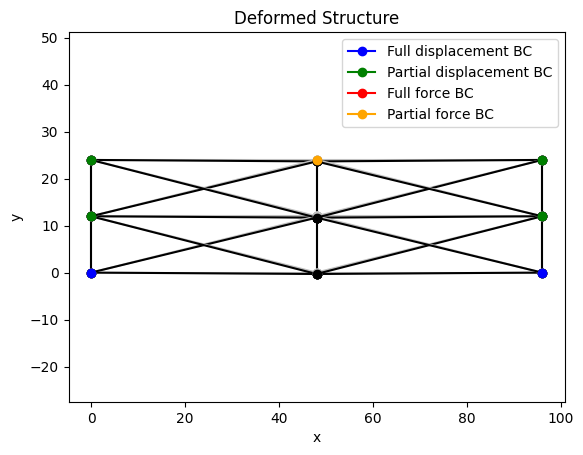

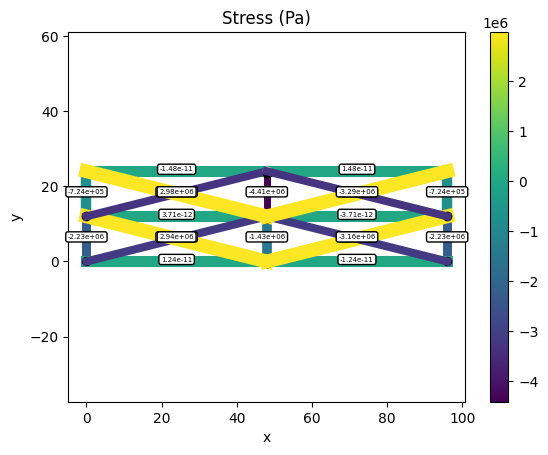

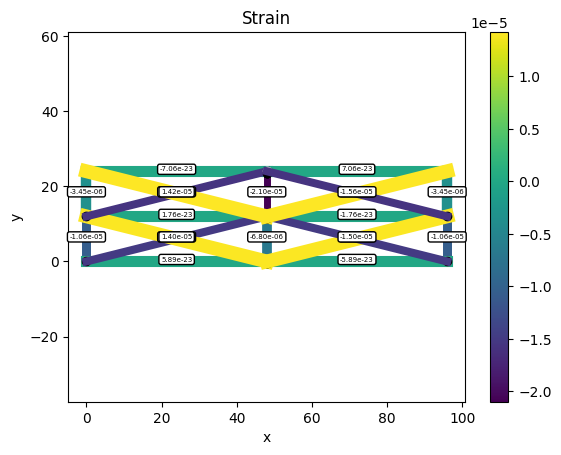

In [185]:
SCALEFACTOR = 1e2 # Magnify deformation for visibility

# Plot Deformed Shape
libTruss.plotResults(Nodes, Connectivity, Ufull, 
                     bc={'force':forceBC, 'disp':dispBC}, 
                     title="Deformed Structure", 
                     scaleFactor=SCALEFACTOR)

# Plot Stress
libTruss.plotResults(Nodes, Connectivity, Ufull, stressElem, 
                     title="Stress (Pa)", 
                     scaleFactor=SCALEFACTOR)

# Plot Strain
libTruss.plotResults(Nodes, Connectivity, Ufull, strainElem, 
                     title="Strain", 
                     scaleFactor=SCALEFACTOR)

## Optimization

In [186]:
from scipy.optimize import minimize

# --- 1. Objective Function: Minimize Mass ---
def objective_mass(areas):
    # Ensure areas are positive to avoid errors during intermediate steps
    areas = np.abs(areas) 
    
    # Calculate mass using your dev library
    mass, _, _ = libTruss_dev.parametricFE(Nodes, Connectivity, areas, loads_list, bc_indices, mat.E, mat.rho)
    return mass

# --- 2. Constraint Function: Stress < Yield Limit ---
def constraint_stress(areas):
    areas = np.abs(areas)
    
    # Run simulation to get current stresses
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, areas, loads_list, bc_indices, mat.E, mat.rho)
    
    # Constraint logic: value must be non-negative (>= 0)
    # Safety Margin = Yield Limit - |Current Stress|
    # If Margin < 0, the constraint is violated.
    return mat.sigl - np.abs(stresses)


# --- Pre-calculate Bar Lengths (Constant) ---
# We calculate this once so we don't repeat it inside the loop
bar_lengths = []
for n1_idx, n2_idx in Connectivity:
    dist = np.linalg.norm(Nodes[n2_idx] - Nodes[n1_idx])
    bar_lengths.append(dist)
bar_lengths = np.array(bar_lengths)

# --- Define Buckling Constraint ---
def constraint_buckling(areas):
    areas = np.abs(areas)
    
    # 1. Get internal stresses from solver
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, areas, loads_list, bc_indices, mat.E, mat.rho)
    
    # 2. Calculate Internal Forces (Force = Stress * Area)
    # Positive = Tension, Negative = Compression
    forces = stresses * areas
    
    # 3. Calculate Critical Buckling Load (Euler's Formula)
    # P_crit = (pi^2 * E * I) / L^2
    # Assumption: Solid Circular Cross-section -> I = A^2 / (4 * pi)
    moment_of_inertia = (areas ** 2) / (4 * np.pi)
    p_crit = (np.pi**2 * mat.E * moment_of_inertia) / (bar_lengths**2)
    
    # 4. Constraint Rule: P_crit + Force >= 0
    # Logic:
    # - If Force is Tension (>0): P_crit + Force is positive (Safe)
    # - If Force is Compression (<0): We need P_crit > |Force|, so P_crit + (-Force) >= 0
    return p_crit + forces

print("Buckling constraint defined.")

print("Optimization functions defined.")

Buckling constraint defined.
Optimization functions defined.


## SLSQP

Starting Scaled Optimization (Variable: cm^2)...
Initial Scaled Guess Mass: 29703.65 kg
Optimization terminated successfully    (Exit mode 0)
            Current function value: 15.312844041158195
            Iterations: 78
            Function evaluations: 1597
            Gradient evaluations: 76

Optimization Success: True
Message: Optimization terminated successfully
Final Mass: 15312.84 kg

Plotting result...


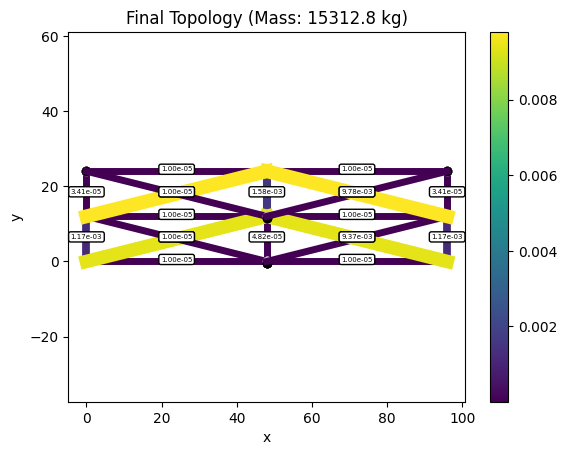

In [187]:
# --- SCALED OPTIMIZATION ---

# 1. Scaling Factor: We optimize in cm^2, convert to m^2 for FEA
# This keeps variables in the range [0.1, 100] instead of [0.00001, 0.01]
scale_factor = 1e-4  # 1 cm^2 = 0.0001 m^2

def get_areas(x_scaled):
    return x_scaled * scale_factor

# 2. Scaled Objective
def objective_mass_scaled(x_scaled):
    areas = get_areas(x_scaled)
    # FEA
    mass, _, _ = libTruss_dev.parametricFE(Nodes, Connectivity, np.abs(areas), loads_list, bc_indices, mat.E, mat.rho)
    # We also scale the mass down by 1000 so the objective isn't huge (optional but helps)
    return mass / 1000.0 

# 3. Scaled Constraints
def constraint_stress_scaled(x_scaled):
    areas = get_areas(x_scaled)
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, np.abs(areas), loads_list, bc_indices, mat.E, mat.rho)
    # Normalized: (Yield - Stress) / Yield
    return (mat.sigl - np.abs(stresses)) / mat.sigl

def constraint_buckling_scaled(x_scaled):
    areas = get_areas(x_scaled)
    areas = np.abs(areas) # Safety
    
    # FEA
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, areas, loads_list, bc_indices, mat.E, mat.rho)
    
    # Physics
    forces = stresses * areas
    moment_of_inertia = (areas ** 2) / (4 * np.pi)
    p_crit = (np.pi**2 * mat.E * moment_of_inertia) / (bar_lengths**2)
    
    # Normalized: (P_crit + Force) / Reference_Load
    # If Force is -10kN and P_crit is 12kN, result is positive (Safe)
    return (p_crit + forces) / 1e4 

# --- 4. Setup Optimization ---
print("Starting Scaled Optimization (Variable: cm^2)...")
n_bars = len(Connectivity)

# Bounds in cm^2
# Min: 0.1 cm^2 (10 mm^2), Max: 100 cm^2
# We relax the upper bound to ensure the initial guess is valid
bounds_scaled = [(0.1, 150.0) for _ in range(n_bars)]

# Initial Guess in cm^2
# Start 'Thick' to be safe: 50 cm^2
x0_scaled = np.ones(n_bars) * 50.0 

# Check Initial State
initial_mass = objective_mass_scaled(x0_scaled) * 1000
print(f"Initial Scaled Guess Mass: {initial_mass:.2f} kg")

cons_scaled = [
    {'type': 'ineq', 'fun': constraint_stress_scaled},
    {'type': 'ineq', 'fun': constraint_buckling_scaled}
]

# --- 5. Run SLSQP ---
result = minimize(objective_mass_scaled, 
                  x0_scaled, 
                  method='SLSQP', 
                  bounds=bounds_scaled,
                  constraints=cons_scaled,
                  options={'maxiter': 1000, 'ftol': 1e-6, 'disp': True})

# --- 6. Process Results ---
final_areas = get_areas(result.x)
final_mass, final_sig, final_u = libTruss_dev.parametricFE(Nodes, Connectivity, final_areas, loads_list, bc_indices, mat.E, mat.rho)

print(f"\nOptimization Success: {result.success}")
print(f"Message: {result.message}")
print(f"Final Mass: {final_mass:.2f} kg")

# Visualize Results (Hiding tiny bars)
print("\nPlotting result...")
libTruss.plotResults(Nodes, Connectivity, final_u, final_areas, 
                     title=f"Final Topology (Mass: {final_mass:.1f} kg)", 
                     scaleFactor=5e2)

### Verification

In [188]:
# --- VERIFICATION & UTILIZATION REPORT ---

# 1. Retrieve Final Areas (Recalculate from scaled values)
# Ensure we use the same scale factor as the optimization
scale_factor = 1e-4 
final_areas_m2 = result.x * scale_factor

# 2. Run Physics Simulation one last time
mass, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, final_areas_m2, loads_list, bc_indices, mat.E, mat.rho)
forces = stresses * final_areas_m2

# 3. Calculate Capacities
# Buckling Capacity (P_crit)
I_final = (final_areas_m2 ** 2) / (4 * np.pi) # Assuming solid circular section approx
P_crit = (np.pi**2 * mat.E * I_final) / (bar_lengths**2)

# Yield Capacity (Force_yield)
F_yield = mat.sigl * final_areas_m2

# 4. Generate Report
print(f"{'Bar ID':<8} {'Area (cm2)':<12} {'Force (N)':<12} {'Stress %':<10} {'Buckling %':<12} {'Status'}")
print("-" * 70)

max_utilization = 0
limiting_bar = -1

for i in range(len(Connectivity)):
    area_cm2 = final_areas_m2[i] * 10000
    force = forces[i]
    
    # Stress Utilization (Compression or Tension)
    stress_util = abs(stresses[i]) / mat.sigl * 100
    
    # Buckling Utilization (Only if Compression < 0)
    buckling_util = 0.0
    if force < 0: # Compression
        buckling_util = abs(force) / P_crit[i] * 100
    
    # Determine Status
    global_util = max(stress_util, buckling_util)
    
    # Track the "Bottleneck"
    if global_util > max_utilization:
        max_utilization = global_util
        limiting_bar = i
    
    # Filter: Only show "Active" bars (Area > 1 cm2) or "Critical" bars
    # This keeps the list clean.
    if area_cm2 > 1.0 or global_util > 50:
        status = "OK"
        if global_util > 99.0: status = "LIMIT"
        if global_util > 100.1: status = "FAIL"
        
        print(f"{i:<8} {area_cm2:<12.2f} {force:<12.0f} {stress_util:<10.1f} {buckling_util:<12.1f} {status}")

print("-" * 70)
print(f"Total Mass: {mass:.2f} kg")
print(f"Maximum Utilization: {max_utilization:.2f}% (Bar {limiting_bar})")

if max_utilization < 90:
    print("\n[ANALYSIS] The result is SUB-OPTIMAL.")
    print("The structure is safe, but heavier than necessary.")
    print("Reason: The optimizer stopped early. Try reducing 'ftol' or increasing 'maxiter'.")
elif max_utilization > 100.1:
    print("\n[ANALYSIS] The result is INVALID.")
    print("The structure is failing constraints.")
else:
    print("\n[ANALYSIS] The result is EXCELLENT.")
    print("The critical bars are fully utilized (~100%). You cannot remove more mass without failure.")

Bar ID   Area (cm2)   Force (N)    Stress %   Buckling %   Status
----------------------------------------------------------------------
0        11.69        -1566        0.5        100.0        LIMIT
1        0.48         -3           0.0        100.0        LIMIT
2        11.69        -1566        0.5        100.0        LIMIT
3        0.34         -1           0.0        100.0        LIMIT
4        15.84        -2873        0.7        100.0        LIMIT
5        0.34         -1           0.0        100.0        LIMIT
12       93.67        -5912        0.3        100.0        LIMIT
15       93.67        -5912        0.3        100.0        LIMIT
16       97.82        -6446        0.3        100.0        LIMIT
19       97.82        -6446        0.3        100.0        LIMIT
----------------------------------------------------------------------
Total Mass: 15312.84 kg
Maximum Utilization: 100.00% (Bar 16)

[ANALYSIS] The result is EXCELLENT.
The critical bars are fully utilized (~100%

## Cobyla 

Starting Optimization (COBYLA)...


C:\Users\moume\AppData\Local\Temp\ipykernel_4452\548217693.py:65: OptimizeWarning: Unknown solver options: ftol
  result = minimize(


Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 1000   Least value of F = 17.174994419027428   Constraint violation = 1.2817254810215672e-08
The corresponding X is:
[2.47587533e+01 2.62467863e+01 1.83825300e+01 6.59303747e+01
 1.54434184e+01 8.47368347e+01 1.00000000e-01 1.00000000e-01
 1.00000000e-01 1.00000000e-01 1.00000000e-01 9.97629248e-01
 9.13326180e+01 1.00000000e-01 1.01891268e-01 9.13315239e+01
 1.00005088e+02 1.00000000e-01 1.00000000e-01 9.99990913e+01]
The constraint value is:
[-2.46587533e+01 -2.61467863e+01 -1.82825300e+01 -6.58303747e+01
 -1.53434184e+01 -8.46368347e+01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.97629248e-01
 -9.12326180e+01  0.00000000e+00 -1.89126806e-03 -9.12315239e+01
 -9.99050877e+01  0.00000000e+00  0.00000000e+00 -9.98990913e+01
 -1.25241247e+02 -1.23753214e+02 -1.31617470e+02 -8.40696253e+01
 -1.34556582e+02 -6.52631653e+01 -1.49900000e+02 -1

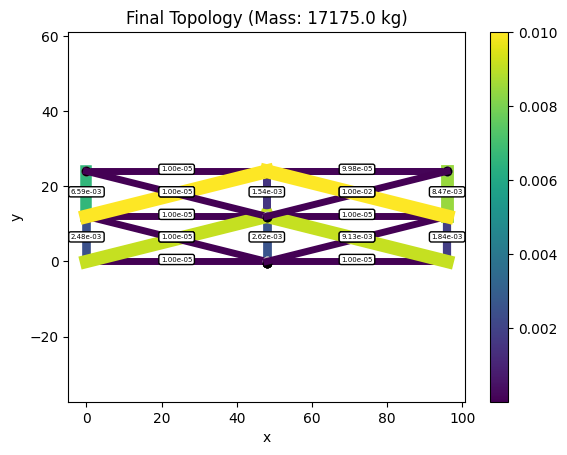


Bar ID   Area (cm2)   Force (N)    Stress %   Buckling %   Status
---------------------------------------------------------------------------
0        24.76        -1637        0.3        23.3         OK
1        26.25        -3           0.0        0.0          OK
2        18.38        -1637        0.4        42.3         OK
3        65.93        -1           0.0        0.0          OK
4        15.44        -2732        0.7        100.0        LIMIT
5        84.74        -1           0.0        0.0          OK
6        0.10         -0           0.0        100.0        LIMIT
11       1.00         -1           0.0        100.0        LIMIT
12       91.33        -5620        0.2        100.0        LIMIT
15       91.33        -5620        0.2        100.0        LIMIT
16       100.01       -6738        0.3        100.0        LIMIT
19       100.00       -6737        0.3        100.0        LIMIT
---------------------------------------------------------------------------
Total Mass: 1717

In [191]:
import numpy as np
from scipy.optimize import minimize

# --- Configuration & Constants ---
SCALE_FACTOR = 1e-4
AREA_DISPLAY_THRESHOLD = 1.0  # cm^2
UTILIZATION_WARN_THRESHOLD = 50.0 # %
MAX_ITER = 1000
FTOL = 1e-6

def generate_verification_report(areas, forces, stresses, lengths, material):
    """
    Generates a detailed console report on bar utilization, buckling, and yield.
    Assumes a solid circular cross-section for buckling calculations.
    """
    # 1. Calculate Capacities
    # Moment of Inertia for solid circle: I = A^2 / (4*pi)
    I_vals = (areas ** 2) / (4 * np.pi) 
    
    # Critical Buckling Load (Euler)
    P_crit = (np.pi**2 * material.E * I_vals) / (lengths**2)
    
    # Yield Force
    F_yield = material.sigl * areas

    # 2. Print Header
    print(f"\n{'Bar ID':<8} {'Area (cm2)':<12} {'Force (N)':<12} {'Stress %':<10} {'Buckling %':<12} {'Status'}")
    print("-" * 75)

    max_utilization = 0.0
    limiting_bar = -1

    # 3. Iterate Bars
    for i, (area, force, stress, length) in enumerate(zip(areas, forces, stresses, lengths)):
        area_cm2 = area * 10000
        
        # Stress Utilization (Compression or Tension)
        stress_util = abs(stress) / material.sigl * 100.0
        
        # Buckling Utilization (Only valid for Compression < 0)
        buckling_util = (abs(force) / P_crit[i] * 100.0) if force < 0 else 0.0
        
        # Global Utilization for this bar
        global_util = max(stress_util, buckling_util)
        
        # Track Bottleneck
        if global_util > max_utilization:
            max_utilization = global_util
            limiting_bar = i
        
        # Filter for cleaner output: Show only active or critical bars
        if area_cm2 > AREA_DISPLAY_THRESHOLD or global_util > UTILIZATION_WARN_THRESHOLD:
            status = "OK"
            if global_util > 99.0: status = "LIMIT"
            if global_util > 100.1: status = "FAIL"
            
            print(f"{i:<8} {area_cm2:<12.2f} {force:<12.0f} {stress_util:<10.1f} {buckling_util:<12.1f} {status}")

    print("-" * 75)
    return max_utilization, limiting_bar

# --- 1. Run Optimization ---
print("Starting Optimization (COBYLA)...")

result = minimize(
    objective_mass_scaled, 
    x0_scaled, 
    method='COBYLA', 
    bounds=bounds_scaled,
    constraints=cons_scaled,
    options={'maxiter': MAX_ITER, 'ftol': FTOL, 'disp': True}
)

# --- 2. Process Final Results ---
# Retrieve physical areas (Assuming get_areas handles the unscaling correctly)
final_areas_m2 = get_areas(result.x)

# Run final FE Analysis
final_mass, final_sig, final_u = libTruss_dev.parametricFE(
    Nodes, Connectivity, final_areas_m2, loads_list, bc_indices, mat.E, mat.rho
)
final_forces = final_sig * final_areas_m2

# Output Summary
print(f"\nOptimization Success: {result.success}")
print(f"Message:      {result.message}")
print(f"Final Mass:   {final_mass:.2f} kg")

# --- 3. Visualize Results ---
print("\nPlotting result...")
libTruss.plotResults(
    Nodes, Connectivity, final_u, final_areas_m2, 
    title=f"Final Topology (Mass: {final_mass:.1f} kg)", 
    scaleFactor=5e2
)

# --- 4. Verification & Utilization Report ---
max_util, limit_bar_id = generate_verification_report(
    areas=final_areas_m2,
    forces=final_forces,
    stresses=final_sig,
    lengths=bar_lengths,
    material=mat
)

print(f"Total Mass: {final_mass:.2f} kg")
print(f"Maximum Utilization: {max_util:.2f}% (Bar {limit_bar_id})")

# --- 5. Final Analysis Statement ---
if max_util < 90.0:
    print("\n[ANALYSIS] The result is SUB-OPTIMAL.")
    print("The structure is safe, but heavier than necessary.")
    print("Recommendation: The optimizer stopped early. Try reducing 'ftol' or increasing 'maxiter'.")
elif max_util > 100.1:
    print("\n[ANALYSIS] The result is INVALID.")
    print("The structure is failing constraints.")
else:
    print("\n[ANALYSIS] The result is EXCELLENT.")
    print("The critical bars are fully utilized (~100%). You cannot remove more mass without failure.")

## COBYQA

Starting Optimization (COBYQA)...
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 10000.
Maximum number of iterations: 1000.

objective_mass_scaled([ 5.000e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = 29.703652904330312
constraint_stress_scaled([ 5.000e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = [ 9.982e-01  9.989e-01 ...  9.976e-01  9.974e-01]
constraint_buckling_scaled([ 5.000e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = [ 2.640e+00  2.721e+00 ...  4.668e-01 -1.601e-01]
objective_mass_scaled([ 5.100e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = 29.713084904330312
constraint_stress_scaled([ 5.100e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = [ 9.982e-01  9.989e-01 ...  9.976e-01  9.974e-01]
constraint_buckling_scaled([ 5.100e+01  5.000e+01 ...  5.000e+01  5.000e+01]) = [ 2.756e+00  2.721e+00 ...  4.668e-01 -1.601e-01]
objective_mass_scaled([ 5.000e+01  5.100e+01 ...  5.000e+01  5.000e+01]) 

C:\Users\moume\AppData\Local\Temp\ipykernel_4452\564605453.py:58: OptimizeWarning: Unknown solver options: ftol
  result = minimize(


objective_mass_scaled([ 4.981e+01  4.985e+01 ...  5.097e+01  5.151e+01]) = 29.878086859787032
constraint_stress_scaled([ 4.981e+01  4.985e+01 ...  5.097e+01  5.151e+01]) = [ 9.982e-01  9.989e-01 ...  9.977e-01  9.974e-01]
constraint_buckling_scaled([ 4.981e+01  4.985e+01 ...  5.097e+01  5.151e+01]) = [ 2.620e+00  2.705e+00 ...  4.719e-01 -1.511e-01]
objective_mass_scaled([ 4.969e+01  4.976e+01 ...  5.154e+01  5.252e+01]) = 29.96292287629754
constraint_stress_scaled([ 4.969e+01  4.976e+01 ...  5.154e+01  5.252e+01]) = [ 9.982e-01  9.989e-01 ...  9.977e-01  9.975e-01]
constraint_buckling_scaled([ 4.969e+01  4.976e+01 ...  5.154e+01  5.252e+01]) = [ 2.606e+00  2.695e+00 ...  4.745e-01 -1.457e-01]
objective_mass_scaled([ 4.952e+01  4.962e+01 ...  5.227e+01  5.400e+01]) = 30.079679216299287
constraint_stress_scaled([ 4.952e+01  4.962e+01 ...  5.227e+01  5.400e+01]) = [ 9.982e-01  9.989e-01 ...  9.978e-01  9.975e-01]
constraint_buckling_scaled([ 4.952e+01  4.962e+01 ...  5.227e+01  5.400e+01

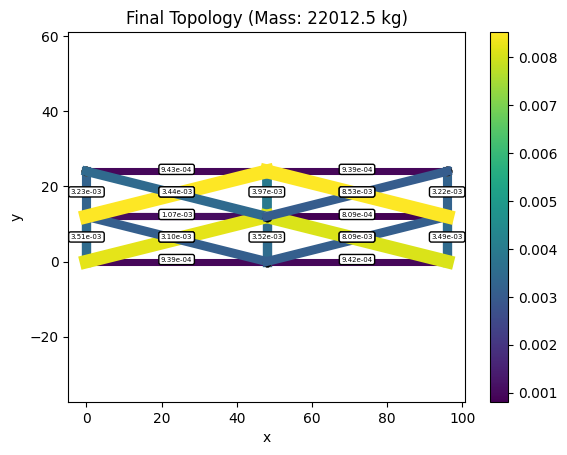


Bar ID   Area (cm2)   Force (N)    Stress %   Buckling %   Status
---------------------------------------------------------------------------
0        35.10        -1950        0.2        13.8         OK
1        35.17        -747         0.1        5.3          OK
2        34.86        -1912        0.2        13.7         OK
3        32.29        -413         0.1        3.5          OK
4        39.75        -3672        0.4        20.3         OK
5        32.22        -375         0.0        3.2          OK
6        9.39         0            0.0        0.0          OK
7        9.42         -0           0.0        0.2          OK
8        10.73        -6           0.0        7.1          OK
9        8.09         4            0.0        0.0          OK
10       9.43         -0           0.0        0.3          OK
11       9.39         0            0.0        0.0          OK
12       82.06        -4480        0.2        98.7         OK
13       31.05        1539         0.2        0.0  

In [192]:
import numpy as np
from scipy.optimize import minimize

# --- Configuration ---
AREA_DISPLAY_THRESHOLD = 1.0  # cm^2
UTILIZATION_WARN_THRESHOLD = 50.0  # %
MAX_ITER = 1000
FTOL = 1e-6

def generate_verification_report(areas, forces, stresses, lengths, material):
    """
    Generates a detailed console report on bar utilization, buckling, and yield.
    Assumes a solid circular cross-section for buckling calculations.
    """
    # 1. Calculate Capacities
    # Moment of Inertia for solid circle: I = A^2 / (4*pi)
    I_vals = (areas ** 2) / (4 * np.pi) 
    
    # Critical Buckling Load (Euler)
    P_crit = (np.pi**2 * material.E * I_vals) / (lengths**2)
    
    print(f"\n{'Bar ID':<8} {'Area (cm2)':<12} {'Force (N)':<12} {'Stress %':<10} {'Buckling %':<12} {'Status'}")
    print("-" * 75)

    max_utilization = 0.0
    limiting_bar = -1

    for i, (area, force, stress) in enumerate(zip(areas, forces, stresses)):
        area_cm2 = area * 10000
        
        # Stress Utilization
        stress_util = abs(stress) / material.sigl * 100.0
        
        # Buckling Utilization (Only valid if Compression < 0)
        buckling_util = (abs(force) / P_crit[i] * 100.0) if force < 0 else 0.0
        
        global_util = max(stress_util, buckling_util)
        
        # Track Bottleneck
        if global_util > max_utilization:
            max_utilization = global_util
            limiting_bar = i
        
        # Filter output
        if area_cm2 > AREA_DISPLAY_THRESHOLD or global_util > UTILIZATION_WARN_THRESHOLD:
            status = "OK"
            if global_util > 99.0: status = "LIMIT"
            if global_util > 100.1: status = "FAIL"
            
            print(f"{i:<8} {area_cm2:<12.2f} {force:<12.0f} {stress_util:<10.1f} {buckling_util:<12.1f} {status}")

    print("-" * 75)
    return max_utilization, limiting_bar

# --- 1. Run Optimization (COBYQA) ---
print("Starting Optimization (COBYQA)...")

result = minimize(
    objective_mass_scaled, 
    x0_scaled, 
    method='COBYQA', 
    bounds=bounds_scaled,
    constraints=cons_scaled,
    options={'maxiter': MAX_ITER, 'ftol': FTOL, 'disp': True}
)

# --- 2. Process Final Results ---
# Retrieve physical areas using the standard helper function
final_areas = get_areas(result.x)

# Run final Physics Simulation
final_mass, final_sig, final_u = libTruss_dev.parametricFE(
    Nodes, Connectivity, final_areas, loads_list, bc_indices, mat.E, mat.rho
)
final_forces = final_sig * final_areas

# Summary Output
print(f"\nOptimization Success: {result.success}")
print(f"Message:      {result.message}")
print(f"Final Mass:   {final_mass:.2f} kg")

# --- 3. Visualize Results ---
print("\nPlotting result...")
libTruss.plotResults(
    Nodes, Connectivity, final_u, final_areas, 
    title=f"Final Topology (Mass: {final_mass:.1f} kg)", 
    scaleFactor=5e2
)

# --- 4. Verification & Utilization Report ---
max_util, limit_bar_id = generate_verification_report(
    areas=final_areas,
    forces=final_forces,
    stresses=final_sig,
    lengths=bar_lengths,
    material=mat
)

print(f"Total Mass: {final_mass:.2f} kg")
print(f"Maximum Utilization: {max_util:.2f}% (Bar {limit_bar_id})")

# --- 5. Analysis Logic ---
if max_util < 90.0:
    print("\n[ANALYSIS] The result is SUB-OPTIMAL.")
    print("The structure is safe, but heavier than necessary.")
    print("Recommendation: The optimizer stopped early. Try reducing 'ftol' or increasing 'maxiter'.")
elif max_util > 100.1:
    print("\n[ANALYSIS] The result is INVALID.")
    print("The structure is failing constraints.")
else:
    print("\n[ANALYSIS] The result is EXCELLENT.")
    print("The critical bars are fully utilized (~100%). You cannot remove more mass without failure.")

## Comparison Script: COBYLA vs COBYQA vs SLSQP

Solver     Time (s)   Final Mass (kg) Iterations Success   
-----------------------------------------------------------------
COBYLA     2.75       17773.04        302        False     
COBYQA     8.72       22012.52        148        True      
SLSQP      2.07       15312.84        78         True      


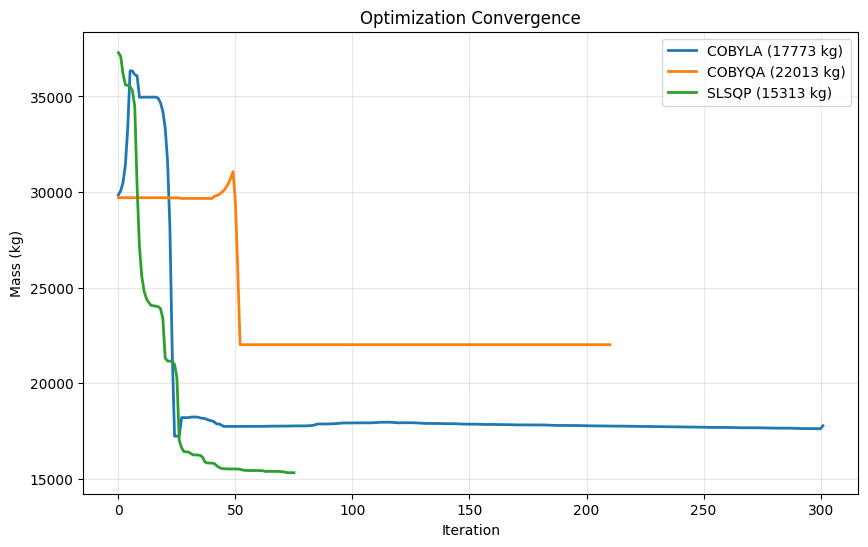


[WINNER] SLSQP produced the lightest design.
Generating detailed report for the winning design...


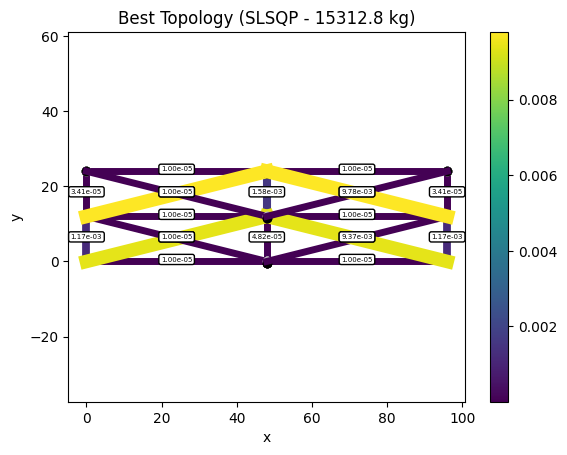


Bar ID   Area (cm2)   Force (N)    Stress %   Buckling %   Status
---------------------------------------------------------------------------
0        11.69        -1566        0.5        100.0        LIMIT
1        0.48         -3           0.0        100.0        LIMIT
2        11.69        -1566        0.5        100.0        LIMIT
3        0.34         -1           0.0        100.0        LIMIT
4        15.84        -2873        0.7        100.0        LIMIT
5        0.34         -1           0.0        100.0        LIMIT
12       93.67        -5912        0.3        100.0        LIMIT
15       93.67        -5912        0.3        100.0        LIMIT
16       97.82        -6446        0.3        100.0        LIMIT
19       97.82        -6446        0.3        100.0        LIMIT


(np.float64(100.00000071148112), 16)

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

# --- 1. Configuration & Constants ---
SCALE_FACTOR = 1e-4          # Converts optimization vars (cm^2) to physical (m^2)
MAX_ITER = 500               # Max iterations per solver
FTOL = 1e-6                  # Convergence tolerance
AREA_DISPLAY_THRESHOLD = 1.0 # Only show bars > 1cm^2 in report

# --- 2. Shared Helper Functions ---

def get_areas(x_scaled):
    """Convert optimization variables (cm^2) to physical areas (m^2)."""
    return x_scaled * SCALE_FACTOR

def generate_verification_report(areas, forces, stresses, lengths, material):
    """Generates a detailed engineering report on the final structure."""
    I_vals = (areas ** 2) / (4 * np.pi) 
    P_crit = (np.pi**2 * material.E * I_vals) / (lengths**2)
    
    print(f"\n{'Bar ID':<8} {'Area (cm2)':<12} {'Force (N)':<12} {'Stress %':<10} {'Buckling %':<12} {'Status'}")
    print("-" * 75)

    max_utilization = 0.0
    limiting_bar = -1

    for i, (area, force, stress) in enumerate(zip(areas, forces, stresses)):
        area_cm2 = area * 10000
        stress_util = abs(stress) / material.sigl * 100.0
        buckling_util = (abs(force) / P_crit[i] * 100.0) if force < 0 else 0.0
        
        global_util = max(stress_util, buckling_util)
        
        if global_util > max_utilization:
            max_utilization = global_util
            limiting_bar = i
        
        if area_cm2 > AREA_DISPLAY_THRESHOLD or global_util > 50.0:
            status = "OK"
            if global_util > 99.0: status = "LIMIT"
            if global_util > 100.1: status = "FAIL"
            print(f"{i:<8} {area_cm2:<12.2f} {force:<12.0f} {stress_util:<10.1f} {buckling_util:<12.1f} {status}")

    return max_utilization, limiting_bar

# --- 3. Physics & Optimization Functions ---

# Pre-calculate bar lengths (Constant)
bar_lengths = np.array([np.linalg.norm(Nodes[n2] - Nodes[n1]) for n1, n2 in Connectivity])

def objective_mass_scaled(x_scaled):
    areas = get_areas(x_scaled)
    # Return mass / 1000 for optimizer numerical stability
    mass, _, _ = libTruss_dev.parametricFE(Nodes, Connectivity, np.abs(areas), loads_list, bc_indices, mat.E, mat.rho)
    return mass / 1000.0

def constraint_stress_scaled(x_scaled):
    areas = get_areas(x_scaled)
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, np.abs(areas), loads_list, bc_indices, mat.E, mat.rho)
    return (mat.sigl - np.abs(stresses)) / mat.sigl

def constraint_buckling_scaled(x_scaled):
    areas = get_areas(x_scaled)
    _, stresses, _ = libTruss_dev.parametricFE(Nodes, Connectivity, np.abs(areas), loads_list, bc_indices, mat.E, mat.rho)
    forces = stresses * areas
    I_vals = (areas ** 2) / (4 * np.pi)
    p_crit = (np.pi**2 * mat.E * I_vals) / (bar_lengths**2)
    # Normalized constraint: (P_crit + Force) must be >= 0
    return (p_crit + forces) / 1e4 

# --- 4. Setup Optimization ---
n_bars = len(Connectivity)
x0_scaled = np.ones(n_bars) * 50.0 # Start with 50 cm^2
bounds_scaled = [(0.1, 150.0) for _ in range(n_bars)] # 0.1 cm^2 to 150 cm^2

cons = [
    {'type': 'ineq', 'fun': constraint_stress_scaled},
    {'type': 'ineq', 'fun': constraint_buckling_scaled}
]

# --- 5. Run Comparison Loop ---
solvers = ['COBYLA', 'COBYQA', 'SLSQP']
results_data = {}

print(f"{'Solver':<10} {'Time (s)':<10} {'Final Mass (kg)':<15} {'Iterations':<10} {'Success':<10}")
print("-" * 65)

for method in solvers:
    history = []
    
    # Callback to track convergence
    def callback_tracker(xk):
        mass = objective_mass_scaled(xk) * 1000.0
        history.append(mass)

    # --- FIX: Handle Solver-Specific Options ---
    # COBYLA uses 'tol' as a main argument, SLSQP uses 'ftol' in options
    run_options = {'maxiter': MAX_ITER, 'disp': False}
    
    if method == 'SLSQP':
        run_options['ftol'] = FTOL
    elif method == 'COBYQA':
         # COBYQA (if available) often accepts standard scipy options
        pass 

    start_time = time.time()
    
    try:
        res = minimize(
            objective_mass_scaled,
            x0_scaled,
            method=method,
            bounds=bounds_scaled,
            constraints=cons,
            callback=callback_tracker,
            tol=FTOL, # COBYLA reads this
            options=run_options
        )
        
        elapsed = time.time() - start_time
        final_mass = objective_mass_scaled(res.x) * 1000.0
        
        # Ensure history captures final step
        if not history: history.append(final_mass)
        if abs(history[-1] - final_mass) > 1.0: history.append(final_mass)
            
        print(f"{method:<10} {elapsed:<10.2f} {final_mass:<15.2f} {res.nit if hasattr(res, 'nit') else len(history):<10} {str(res.success):<10}")
        
        results_data[method] = {'res': res, 'mass': final_mass, 'history': history}
        
    except Exception as e:
        print(f"{method:<10} FAILED: {str(e)}")

# --- 6. Plot Convergence ---
plt.figure(figsize=(10, 6))
for method, data in results_data.items():
    plt.plot(data['history'], label=f"{method} ({data['mass']:.0f} kg)", linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Mass (kg)')
plt.title('Optimization Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 7. Final Report for the BEST Result ---
best_solver = min(results_data, key=lambda k: results_data[k]['mass'])
best_res = results_data[best_solver]['res']

print(f"\n[WINNER] {best_solver} produced the lightest design.")
print("Generating detailed report for the winning design...")

# Calculate final physics
final_areas = get_areas(best_res.x)
final_mass, final_sig, final_u = libTruss_dev.parametricFE(Nodes, Connectivity, final_areas, loads_list, bc_indices, mat.E, mat.rho)
final_forces = final_sig * final_areas

# Visualize
libTruss.plotResults(Nodes, Connectivity, final_u, final_areas, 
                     title=f"Best Topology ({best_solver} - {final_mass:.1f} kg)", 
                     scaleFactor=5e2)

# Table
generate_verification_report(final_areas, final_forces, final_sig, bar_lengths, mat)